<a href="https://colab.research.google.com/github/olucasaguiar/projeto-simulacao-opiniao-publica/blob/feature/primeira-tentativa-modelo/simulacao-opiniao-publica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from scipy.spatial.distance import jensenshannon

# 1. Configurações de Features
fx_id_order = ['16 E 17', '18 A 24', '25 A 34', '35 A 44', '45 A 54', '55 A 64', '65 E MAIS']
p4_order = ['Não sabe/ Não respondeu', 'Nenhuma vontade', 'Alguma vontade', 'Muita vontade']
renda_order = ['NÃO RESPONDEU', 'NÃO TEM RENDIMENTO PESSOAL', 'ATÉ 1', 'MAIS DE 1 A 2', 'MAIS DE 2 A 5', 'MAIS DE 5 A 10', 'MAIS DE 10 A 20', 'MAIS DE 20']

ordinal_features = {'FX_ID': fx_id_order, 'P4': p4_order, 'REND1': renda_order, 'REND2': renda_order}
nominal_features = ['SEXO', 'ESCOLARIDADE', 'P1A', 'P1B', 'P1C', 'RACA', 'RELIGIAO', 'REGIAO', 'COND']
s_targets = ['P2_1', 'P3_1']

# 2. Carregamento
df_train = pd.read_csv('https://raw.githubusercontent.com/olucasaguiar/projeto-simulacao-opiniao-publica/main/llm_simulation/data/df_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/olucasaguiar/projeto-simulacao-opiniao-publica/main/llm_simulation/data/df_test.csv')

X_train, X_test = df_train[list(ordinal_features.keys()) + nominal_features], df_test[list(ordinal_features.keys()) + nominal_features]
y_train, y_test = df_train[s_targets], df_test[s_targets]

In [2]:
def simplify_col(df, cols, threshold=0.05):
    df_copy = df.copy()
    for col in cols:
        counts = df_copy[col].value_counts(normalize=True)
        low_freq = counts[counts < threshold].index
        df_copy[col] = df_copy[col].apply(lambda x: 'Outros' if x in low_freq else x)
    return df_copy

def simplify_targets(y_series, threshold=0.03):
    counts = y_series.value_counts(normalize=True)
    to_keep = counts[counts >= threshold].index
    return y_series.apply(lambda x: x if x in to_keep else 'Outros/Diversos')

# Simplificação de Features e Targets
X_train_sim = simplify_col(X_train, nominal_features)
X_test_sim = simplify_col(X_test, nominal_features)

y_train_sim = y_train.copy()
y_test_sim = y_test.copy()
for col in s_targets:
    y_train_sim[col] = simplify_targets(y_train[col])
    y_test_sim[col] = simplify_targets(y_test[col])

# Encoding de Targets
target_encoders = [LabelEncoder() for _ in s_targets]
y_train_enc = np.stack([target_encoders[i].fit_transform(y_train_sim[col]) for i, col in enumerate(s_targets)], axis=1)
y_test_enc = np.stack([target_encoders[i].transform(y_test_sim[col]) for i, col in enumerate(s_targets)], axis=1)

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# Custom scorer for multiclass-multioutput
def multioutput_f1_weighted(y_true, y_pred):
    scores = []
    for i in range(y_true.shape[1]):
        score = f1_score(y_true[:, i], y_pred[:, i], average='weighted')
        scores.append(score)
    return np.mean(scores)

custom_f1_scorer = make_scorer(multioutput_f1_weighted)

preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(categories=[ordinal_features[c] for c in ordinal_features.keys()], handle_unknown='use_encoded_value', unknown_value=-1), list(ordinal_features.keys())),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
])

# Base model
xgb = XGBClassifier(random_state=42, tree_method='hist')
chain = ClassifierChain(xgb, order=[0, 1])

# Define the parameter grid for the base model
param_grid = {
    'estimator__n_estimators': [100, 250],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(chain, param_grid, cv=3, scoring=custom_f1_scorer, n_jobs=-1)

train_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', grid_search)
], verbose=True)

train_pipeline.fit(X_train_sim, y_train_enc)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score (CV): {grid_search.best_score_:.4f}")

# Usar o melhor modelo para predição
classifier = grid_search.best_estimator_
y_pred = train_pipeline.predict(X_test_sim)
print("Modelo otimizado treinado e testado com sucesso.")

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  10.6s
Melhores parâmetros: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 5, 'estimator__n_estimators': 100}
Melhor F1-Score (CV): 0.2043
Modelo otimizado treinado e testado com sucesso.


** Relatório de Métricas (F1-Score) **

Target: P2_1
                                                                               precision    recall  f1-score   support

Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)       0.13      0.06      0.09        31
                                             Incentivar a geração de empregos       0.14      0.11      0.12        37
                                             Melhorar a qualidade da educação       0.14      0.05      0.07        21
                                                Melhorar a qualidade da saúde       0.20      0.51      0.29        35
                                                              Outros/Diversos       0.10      0.06      0.08        16
                                       Preservar os valores ligados à família       0.25      0.11      0.15         9
                                                          Reduzir a violência       0.11      0.11      0.11     

/tmp/ipykernel_27676/1276861065.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


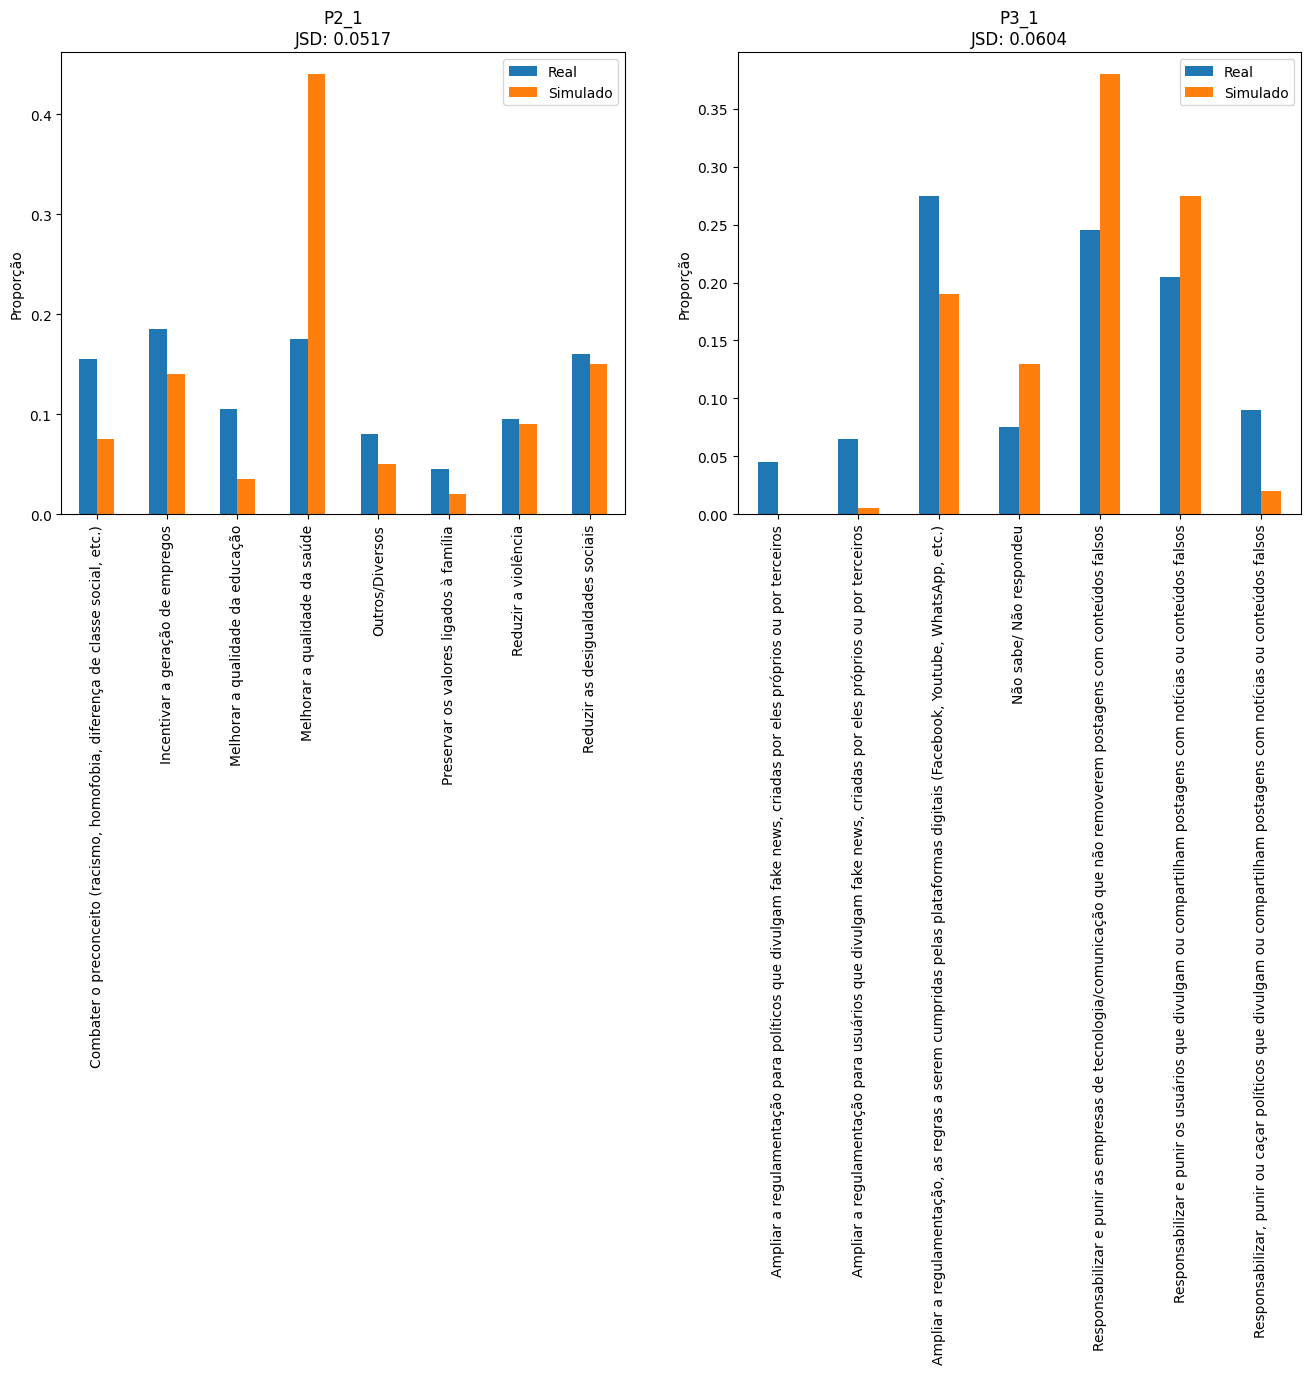

In [4]:
print("** Relatório de Métricas (F1-Score) **")
for i, col in enumerate(s_targets):
    print(f'\nTarget: {col}')
    print(classification_report(y_test_enc[:, i], y_pred[:, i], target_names=target_encoders[i].classes_, zero_division=0))

def calculate_jsd(y_true, y_pred, n_classes):
    p = np.histogram(y_true, bins=range(n_classes + 1), density=True)[0]
    q = np.histogram(y_pred, bins=range(n_classes + 1), density=True)[0]
    return jensenshannon(p, q) ** 2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, col in enumerate(s_targets):
    n_cls = len(target_encoders[i].classes_)
    jsd_val = calculate_jsd(y_test_enc[:, i], y_pred[:, i], n_cls)

    true_dist = pd.Series(y_test_enc[:, i]).value_counts(normalize=True).sort_index()
    pred_dist = pd.Series(y_pred[:, i]).value_counts(normalize=True).sort_index()
    df_dist = pd.DataFrame({'Real': true_dist, 'Simulado': pred_dist}).fillna(0)
    df_dist.index = target_encoders[i].classes_

    df_dist.plot(kind='bar', ax=axes[i], title=f'{col}\nJSD: {jsd_val:.4f}')
    axes[i].set_ylabel('Proporção')

plt.tight_layout()
plt.show()